# Notebook 2 — Lightweight M5 vs M15 LightGBM Walk-Forward Benchmark

**Master's capstone project:** XAUUSD ML/DL trading bot methodology

This notebook performs a **lightweight timeframe-screening benchmark** using LightGBM. It compares M5 and M15 datasets before the full model-training phase.

This notebook is **not** the final LightGBM training notebook. Its purpose is to decide whether M5 or M15 is more defensible for the full walk-forward modelling stage.

## CRISP-DM position

- **Phase:** Modelling, with evaluation support for timeframe selection.
- **Input:** Verified M5/M15 relative feature datasets from the data-preparation stage.
- **Output:** Evidence for selecting the modelling timeframe.

## Tracks compared

1. M5 price-only relative features
2. M5 volume-assisted relative features
3. M15 price-only relative features
4. M15 volume-assisted relative features

The final forward holdout period is **not used** here.

## Methodological rules

1. Use chronological walk-forward folds only.
2. Train only on historical data before validation/test periods.
3. Select probability thresholds using validation data only.
4. Evaluate on the next unseen test window.
5. Keep the final holdout untouched for later final evaluation.
6. Use a fixed lightweight LightGBM configuration. No full hyperparameter tuning is performed here.
7. Save all tables and figures for later review.

This benchmark is intentionally simple because its purpose is timeframe screening, not final model selection.

## 1. Google Drive and project configuration

Set `PROJECT_ROOT` to the folder where your `data/capstone_methodology` folder exists.

Expected structure:

```text
fyp_master_starter/
  data/
    capstone_methodology/
      processed/
      reports/data_quality/
      notebook_outputs/
```

In [1]:
from pathlib import Path
import os
import sys
import json
import math
import warnings
import subprocess

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/fyp_master_starter')
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / 'data' / 'capstone_methodology'
PROCESSED_DIR = DATA_DIR / 'processed'
QUALITY_DIR = DATA_DIR / 'reports' / 'data_quality'
OUTPUT_DIR = DATA_DIR / 'notebook_outputs' / '02_m5_m15_lightgbm_screening'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR = OUTPUT_DIR / 'figures'
MODEL_DIR = OUTPUT_DIR / 'models'

for path in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_DIR:     {DATA_DIR}')
print(f'OUTPUT_DIR:   {OUTPUT_DIR}')

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/fyp_master_starter
DATA_DIR:     /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology
OUTPUT_DIR:   /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening


## 2. Install and import dependencies

LightGBM is used because it is fast, strong for tabular financial features, and suitable as a lightweight screening model before heavier DL training.

In [2]:
try:
    import lightgbm as lgb
except Exception:
    print('Installing lightgbm...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lightgbm'])
    import lightgbm as lgb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    brier_score_loss,
    log_loss,
)

print('lightgbm version:', lgb.__version__)

lightgbm version: 4.6.0


## 3. Experiment settings

The final holdout is intentionally excluded from the benchmark. The benchmark uses development folds ending before 2025.

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

FINAL_HOLDOUT_START = pd.Timestamp('2025-01-01', tz='UTC')

FOLDS = [
    {'fold': 'fold_1', 'train_start': None, 'train_end': '2021-01-01', 'val_start': '2021-01-01', 'val_end': '2022-01-01', 'test_start': '2022-01-01', 'test_end': '2023-01-01'},
    {'fold': 'fold_2', 'train_start': None, 'train_end': '2022-01-01', 'val_start': '2022-01-01', 'val_end': '2023-01-01', 'test_start': '2023-01-01', 'test_end': '2024-01-01'},
    {'fold': 'fold_3', 'train_start': None, 'train_end': '2023-01-01', 'val_start': '2023-01-01', 'val_end': '2024-01-01', 'test_start': '2024-01-01', 'test_end': '2025-01-01'},
]

# Conservative boundary protection because some features use rolling windows.
EMBARGO_BARS = 96

THRESHOLD_GRID = [
    {'upper': 0.51, 'lower': 0.49},
    {'upper': 0.52, 'lower': 0.48},
    {'upper': 0.53, 'lower': 0.47},
]

COST_BPS_GRID = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
SCREENING_COST_BPS = 1.0

MAX_POSITION_CHANGES_PER_DAY = 5
MIN_HOLD_BARS = 2
DAILY_LOSS_STOP = 0.02
TOTAL_DRAWDOWN_STOP = 0.15

# Keep False for capstone output. Use True only to debug notebook mechanics quickly.
QUICK_MODE = False
MAX_TRAIN_ROWS_IF_QUICK = 80_000
MAX_VAL_ROWS_IF_QUICK = 20_000
MAX_TEST_ROWS_IF_QUICK = 20_000

LIGHTGBM_PARAMS = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'n_estimators': 800,
    'learning_rate': 0.03,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 100,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'random_state': RANDOM_SEED,
    'n_jobs': -1,
    'verbosity': -1,
}

print('Final holdout starts:', FINAL_HOLDOUT_START)
print('Development folds:', len(FOLDS))
print('Threshold grid:', THRESHOLD_GRID)
print('Cost grid:', COST_BPS_GRID)

Final holdout starts: 2025-01-01 00:00:00+00:00
Development folds: 3
Threshold grid: [{'upper': 0.51, 'lower': 0.49}, {'upper': 0.52, 'lower': 0.48}, {'upper': 0.53, 'lower': 0.47}]
Cost grid: [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]


## 4. Input file checks

This notebook uses the final model-ready datasets created by the verified data-preparation scripts.

In [4]:
DATASET_PATHS = {
    ('M5', 'price_only'): PROCESSED_DIR / 'dukascopy_xauusd_m5_price_only_relative_dataset.parquet',
    ('M5', 'volume_assisted'): PROCESSED_DIR / 'dukascopy_xauusd_m5_volume_assisted_relative_dataset.parquet',
    ('M15', 'price_only'): PROCESSED_DIR / 'dukascopy_xauusd_m15_price_only_relative_dataset.parquet',
    ('M15', 'volume_assisted'): PROCESSED_DIR / 'dukascopy_xauusd_m15_volume_assisted_relative_dataset.parquet',
}

INTEGRITY_SUMMARY_PATH = QUALITY_DIR / 'dukascopy_xauusd_m5_m15_relative_pipeline_integrity_summary.json'
EDA_SCORE_PATH = DATA_DIR / 'notebook_outputs' / '01_m5_m15_timeframe_feasibility_eda' / 'tables' / 'eda_timeframe_feasibility_score.csv'

missing = [str(path) for path in list(DATASET_PATHS.values()) + [INTEGRITY_SUMMARY_PATH] if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))

with open(INTEGRITY_SUMMARY_PATH, 'r', encoding='utf-8') as f:
    integrity_summary = json.load(f)

print(json.dumps(integrity_summary, indent=2))
if integrity_summary.get('final_status') != 'PASS':
    raise ValueError('Data integrity summary is not PASS. Stop before modelling.')

if EDA_SCORE_PATH.exists():
    print('\nNotebook 1 EDA score found:')
    display(pd.read_csv(EDA_SCORE_PATH))
else:
    print('\nNotebook 1 EDA score not found. This benchmark can still run, but keep Notebook 1 output for report traceability.')

{
  "final_status": "PASS",
  "checks_run": 27,
  "checks_passed": 27,
  "checks_failed": 0,
  "failed_checks": [],
  "scope": "This verification checks internal consistency from M1 master to M5/M15 complete bars, relative model datasets, target alignment and feature policy. It does not compare prices against a second market-data provider."
}

Notebook 1 EDA score found:


,timeframe,rows,mean_abs_return_bps,gaps_per_30_calendar_days,approx_direction_flips_per_24h_if_always_in_market,min_fold_rows,avg_max_feature_psi,score_rows,score_return_magnitude,score_gap_frequency,score_turnover_pressure,score_fold_sufficiency,score_feature_drift,eda_feasibility_score_equal_weight
0,M5,720539,3.624223,30.079907,148.376923,70003,0.252443,1.0,0.0,0.0,0.0,1.0,1.0,0.5
1,M15,237001,6.248668,27.537203,49.592095,22985,0.269181,0.0,1.0,1.0,1.0,0.0,0.0,0.5


## 5. Helper functions

This section defines dataset loading, fold slicing, classification metrics, signal-to-position trading evaluation, and validation-only threshold selection.

In [5]:
TARGET_COLUMNS = {'target_ret_fwd', 'target_dir', 'target_class_3'}
RAW_OHLCV_COLUMNS = {'open', 'high', 'low', 'close', 'volume'}


def timeframe_to_minutes(timeframe: str) -> int:
    return int(timeframe.replace('M', ''))


def load_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_parquet(path)
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'time' not in df.columns:
            raise ValueError(f'{path} has no DatetimeIndex or time column')
        df['time'] = pd.to_datetime(df['time'], utc=True)
        df = df.set_index('time')
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = 'time'
    df = df.sort_index()
    if df.index.duplicated().any():
        raise ValueError(f'{path} has duplicate timestamps')
    if 'target_dir' not in df.columns or 'target_ret_fwd' not in df.columns:
        raise ValueError(f'{path} missing target columns')
    raw_present = sorted(RAW_OHLCV_COLUMNS.intersection(df.columns))
    if raw_present:
        raise ValueError(f'{path} contains raw OHLCV columns in model dataset: {raw_present}')
    return df


def get_feature_columns(df: pd.DataFrame) -> list[str]:
    features = [c for c in df.columns if c not in TARGET_COLUMNS]
    non_numeric = [c for c in features if not pd.api.types.is_numeric_dtype(df[c])]
    if non_numeric:
        raise ValueError(f'Non-numeric feature columns found: {non_numeric}')
    return features


def to_utc(value):
    if value is None:
        return None
    ts = pd.Timestamp(value)
    return ts.tz_localize('UTC') if ts.tzinfo is None else ts.tz_convert('UTC')


def apply_quick_sample(df: pd.DataFrame, max_rows: int | None) -> pd.DataFrame:
    if not QUICK_MODE or max_rows is None or len(df) <= max_rows:
        return df
    return df.iloc[-max_rows:].copy()


def make_fold_splits(df: pd.DataFrame, fold: dict, timeframe: str):
    bar_minutes = timeframe_to_minutes(timeframe)
    embargo_delta = pd.Timedelta(minutes=EMBARGO_BARS * bar_minutes)

    train_start = to_utc(fold['train_start'])
    train_end = to_utc(fold['train_end']) - embargo_delta
    val_start = to_utc(fold['val_start'])
    val_end = to_utc(fold['val_end']) - embargo_delta
    test_start = to_utc(fold['test_start'])
    test_end = to_utc(fold['test_end'])

    if test_end > FINAL_HOLDOUT_START:
        raise ValueError('Fold test period reaches into final holdout.')

    train_mask = df.index < train_end
    if train_start is not None:
        train_mask &= df.index >= train_start

    val_mask = (df.index >= val_start) & (df.index < val_end)
    test_mask = (df.index >= test_start) & (df.index < test_end)

    train = df.loc[train_mask].copy()
    val = df.loc[val_mask].copy()
    test = df.loc[test_mask].copy()

    if train.empty or val.empty or test.empty:
        raise ValueError(f'Empty split in {fold["fold"]} for {timeframe}')

    train = apply_quick_sample(train, MAX_TRAIN_ROWS_IF_QUICK)
    val = apply_quick_sample(val, MAX_VAL_ROWS_IF_QUICK)
    test = apply_quick_sample(test, MAX_TEST_ROWS_IF_QUICK)
    return train, val, test


def classification_metrics(y_true, proba) -> dict:
    proba = np.asarray(proba, dtype=float)
    y_true = np.asarray(y_true, dtype=int)
    pred = (proba >= 0.5).astype(int)
    out = {
        'rows': int(len(y_true)),
        'target_1_rate': float(np.mean(y_true == 1)),
        'proba_mean': float(np.mean(proba)),
        'accuracy': float(accuracy_score(y_true, pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, pred)),
        'f1': float(f1_score(y_true, pred, zero_division=0)),
        'brier': float(brier_score_loss(y_true, proba)),
    }
    if len(np.unique(y_true)) == 2:
        out['roc_auc'] = float(roc_auc_score(y_true, proba))
        out['log_loss'] = float(log_loss(y_true, np.clip(proba, 1e-6, 1 - 1e-6), labels=[0, 1]))
    else:
        out['roc_auc'] = np.nan
        out['log_loss'] = np.nan
    return out


def max_drawdown_from_log_returns(log_returns):
    if len(log_returns) == 0:
        return 0.0
    equity = np.exp(np.cumsum(log_returns))
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1.0
    return float(drawdown.min())


def annualisation_factor(index: pd.DatetimeIndex):
    if len(index) < 2:
        return 1.0
    observed_days = len(pd.Series(index.date).unique())
    rows_per_active_day = len(index) / max(observed_days, 1)
    return float(rows_per_active_day * 252)


def extract_trade_returns(positions, net_log_returns):
    trades = []
    current = 0.0
    in_trade = False
    prev_pos = 0
    for pos, ret in zip(positions, net_log_returns):
        pos = int(pos)
        if pos != 0:
            current += float(ret)
            in_trade = True
        if in_trade and pos == 0 and prev_pos != 0:
            trades.append(current)
            current = 0.0
            in_trade = False
        if in_trade and prev_pos != 0 and pos != prev_pos and pos != 0:
            trades.append(current)
            current = 0.0
        prev_pos = pos
    if in_trade:
        trades.append(current)
    return trades


def signal_backtest(index, proba, target_log_returns, timeframe, upper, lower, cost_bps,
                    max_changes_per_day=MAX_POSITION_CHANGES_PER_DAY,
                    min_hold_bars=MIN_HOLD_BARS,
                    daily_loss_stop=DAILY_LOSS_STOP,
                    total_drawdown_stop=TOTAL_DRAWDOWN_STOP):
    bar_minutes = timeframe_to_minutes(timeframe)
    expected_delta = pd.Timedelta(minutes=bar_minutes)
    cost_per_turnover = cost_bps / 10_000.0

    proba = np.asarray(proba, dtype=float)
    returns = np.asarray(target_log_returns, dtype=float)

    positions = np.zeros(len(index), dtype=np.int8)
    gross_lr = np.zeros(len(index), dtype=float)
    net_lr = np.zeros(len(index), dtype=float)
    turnover = np.zeros(len(index), dtype=float)
    change_events = np.zeros(len(index), dtype=float)

    prev_pos = 0
    hold_count = min_hold_bars
    current_day = None
    daily_pnl = 0.0
    daily_changes = 0
    equity_log = 0.0
    peak_equity_log = 0.0
    stopped_total = False

    for i, ts in enumerate(index):
        day = ts.date()
        if current_day != day:
            current_day = day
            daily_pnl = 0.0
            daily_changes = 0

        if i > 0 and (index[i] - index[i - 1]) != expected_delta:
            prev_pos = 0
            hold_count = min_hold_bars

        raw_signal = 0
        if proba[i] >= upper:
            raw_signal = 1
        elif proba[i] <= lower:
            raw_signal = -1

        desired_pos = raw_signal
        if stopped_total or daily_pnl <= -daily_loss_stop:
            desired_pos = 0

        if desired_pos != prev_pos:
            if hold_count < min_hold_bars:
                desired_pos = prev_pos
            elif daily_changes >= max_changes_per_day:
                desired_pos = prev_pos

        change = abs(desired_pos - prev_pos)
        if change > 0:
            # Count one position-change event, while turnover captures the size of the change.
            # Example: flat -> long is one event and one turnover unit; short -> long is one event and two turnover units.
            daily_changes += 1
            change_events[i] = 1.0
            hold_count = 0
        else:
            hold_count += 1

        positions[i] = desired_pos
        turnover[i] = change
        gross_lr[i] = desired_pos * returns[i]
        net_lr[i] = gross_lr[i] - change * cost_per_turnover

        daily_pnl += net_lr[i]
        equity_log += net_lr[i]
        peak_equity_log = max(peak_equity_log, equity_log)
        drawdown = math.exp(equity_log - peak_equity_log) - 1.0
        if drawdown <= -total_drawdown_stop:
            stopped_total = True
        prev_pos = desired_pos

    ann = annualisation_factor(index)
    active = positions != 0
    total_turnover = float(turnover.sum())
    total_change_events = float(change_events.sum())
    active_days = max(len(pd.Series(index.date).unique()), 1)
    trade_returns = extract_trade_returns(positions, net_lr)
    wins = [x for x in trade_returns if x > 0]
    losses = [x for x in trade_returns if x < 0]

    mean_lr = float(np.mean(net_lr)) if len(net_lr) else 0.0
    std_lr = float(np.std(net_lr, ddof=1)) if len(net_lr) > 1 else 0.0
    downside = net_lr[net_lr < 0]
    downside_std = float(np.std(downside, ddof=1)) if len(downside) > 1 else 0.0

    sharpe = (mean_lr / std_lr * math.sqrt(ann)) if std_lr > 0 else np.nan
    sortino = (mean_lr / downside_std * math.sqrt(ann)) if downside_std > 0 else np.nan

    gross_return = float(math.exp(np.sum(gross_lr)) - 1.0)
    net_return = float(math.exp(np.sum(net_lr)) - 1.0)
    max_dd = max_drawdown_from_log_returns(net_lr)
    profit_factor = float(np.sum(wins) / abs(np.sum(losses))) if losses and abs(np.sum(losses)) > 0 else np.nan

    return {
        'upper_threshold': float(upper),
        'lower_threshold': float(lower),
        'cost_bps': float(cost_bps),
        'gross_return': gross_return,
        'net_return': net_return,
        'sharpe': float(sharpe) if np.isfinite(sharpe) else np.nan,
        'sortino': float(sortino) if np.isfinite(sortino) else np.nan,
        'max_drawdown': max_dd,
        'turnover': total_turnover,
        'trade_count': int(len(trade_returns)),
        'win_rate': float(np.mean(np.array(trade_returns) > 0)) if trade_returns else np.nan,
        'profit_factor': profit_factor,
        'active_bar_rate': float(active.mean()) if len(active) else 0.0,
        'position_change_events': total_change_events,
        'position_change_events_per_day': float(total_change_events / active_days),
        'turnover_units_per_day': float(total_turnover / active_days),
        # Kept for backward compatibility with earlier output files. It now correctly means change events/day.
        'position_changes_per_day': float(total_change_events / active_days),
        'total_drawdown_stop_triggered': bool(stopped_total),
    }


def choose_threshold_on_validation(val_trading_results: pd.DataFrame) -> pd.Series:
    tmp = val_trading_results.copy()
    tmp['max_drawdown_abs'] = tmp['max_drawdown'].abs()
    tmp = tmp.sort_values(
        by=['net_return', 'sharpe', 'max_drawdown_abs', 'turnover'],
        ascending=[False, False, True, True],
    )
    return tmp.iloc[0]

## 6. Fold sufficiency check

Before training, this cell verifies that each fold has enough rows and that the final holdout is not touched.

In [6]:
fold_rows = []

for (timeframe, feature_set), path in DATASET_PATHS.items():
    df = load_dataset(path)
    for fold in FOLDS:
        train, val, test = make_fold_splits(df, fold, timeframe)
        fold_rows.append({
            'timeframe': timeframe,
            'feature_set': feature_set,
            'fold': fold['fold'],
            'train_rows': len(train),
            'validation_rows': len(val),
            'test_rows': len(test),
            'train_start': str(train.index.min()),
            'train_end': str(train.index.max()),
            'validation_start': str(val.index.min()),
            'validation_end': str(val.index.max()),
            'test_start': str(test.index.min()),
            'test_end': str(test.index.max()),
        })

df_fold_rows = pd.DataFrame(fold_rows)
df_fold_rows.to_csv(TABLE_DIR / 'walk_forward_fold_rows.csv', index=False)
display(df_fold_rows)

if (df_fold_rows[['train_rows', 'validation_rows', 'test_rows']] <= 0).any().any():
    raise ValueError('At least one fold has empty train/validation/test rows.')

if pd.to_datetime(df_fold_rows['test_end'], utc=True).max() >= FINAL_HOLDOUT_START:
    raise ValueError('A development fold reaches into the final holdout.')

,timeframe,feature_set,fold,train_rows,validation_rows,test_rows,train_start,train_end,validation_start,validation_end,test_start,test_end
0,M5,price_only,fold_1,350650,70486,70571,2016-01-04 15:45:00+00:00,2020-12-31 15:55:00+00:00,2021-01-03 23:05:00+00:00,2021-12-31 15:55:00+00:00,2022-01-02 23:05:00+00:00,2022-12-30 21:50:00+00:00
1,M5,price_only,fold_2,421208,70571,70003,2016-01-04 15:45:00+00:00,2021-12-31 15:55:00+00:00,2022-01-02 23:05:00+00:00,2022-12-30 21:50:00+00:00,2023-01-02 23:10:00+00:00,2023-12-29 21:50:00+00:00
2,M5,price_only,fold_3,491851,70003,70829,2016-01-04 15:45:00+00:00,2022-12-30 21:50:00+00:00,2023-01-02 23:10:00+00:00,2023-12-29 21:50:00+00:00,2024-01-01 23:05:00+00:00,2024-12-31 21:50:00+00:00
3,M5,volume_assisted,fold_1,350650,70486,70571,2016-01-04 15:45:00+00:00,2020-12-31 15:55:00+00:00,2021-01-03 23:05:00+00:00,2021-12-31 15:55:00+00:00,2022-01-02 23:05:00+00:00,2022-12-30 21:50:00+00:00
4,M5,volume_assisted,fold_2,421208,70571,70003,2016-01-04 15:45:00+00:00,2021-12-31 15:55:00+00:00,2022-01-02 23:05:00+00:00,2022-12-30 21:50:00+00:00,2023-01-02 23:10:00+00:00,2023-12-29 21:50:00+00:00
5,M5,volume_assisted,fold_3,491851,70003,70829,2016-01-04 15:45:00+00:00,2022-12-30 21:50:00+00:00,2023-01-02 23:10:00+00:00,2023-12-29 21:50:00+00:00,2024-01-01 23:05:00+00:00,2024-12-31 21:50:00+00:00
6,M15,price_only,fold_1,114907,23226,23290,2016-01-06 03:15:00+00:00,2020-12-30 23:45:00+00:00,2021-01-03 23:15:00+00:00,2021-12-30 23:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00
7,M15,price_only,fold_2,138221,23290,22985,2016-01-06 03:15:00+00:00,2021-12-30 23:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00
8,M15,price_only,fold_3,161599,22985,23382,2016-01-06 03:15:00+00:00,2022-12-30 21:30:00+00:00,2023-01-02 23:30:00+00:00,2023-12-29 21:30:00+00:00,2024-01-01 23:15:00+00:00,2024-12-31 21:30:00+00:00
9,M15,volume_assisted,fold_1,114907,23226,23290,2016-01-06 03:15:00+00:00,2020-12-30 23:45:00+00:00,2021-01-03 23:15:00+00:00,2021-12-30 23:45:00+00:00,2022-01-02 23:15:00+00:00,2022-12-30 21:30:00+00:00


## 7. Run lightweight LightGBM walk-forward benchmark

For each timeframe and feature set:

1. Train one fixed LightGBM model per fold.
2. Use validation for early stopping.
3. Select trading threshold using validation only.
4. Apply selected threshold to the next unseen test window.
5. Repeat across cost grid.

This is deliberately a screening benchmark, not a tuned final model.

In [7]:
classification_records = []
validation_trading_records = []
test_trading_records = []
selected_threshold_records = []
feature_importance_records = []

for (timeframe, feature_set), path in DATASET_PATHS.items():
    print('=' * 100)
    print(f'Running {timeframe} | {feature_set}')
    print('=' * 100)

    df = load_dataset(path)
    feature_cols = get_feature_columns(df)
    df_dev = df.loc[df.index < FINAL_HOLDOUT_START].copy()
    print(f'Development rows: {len(df_dev):,} | features: {len(feature_cols)}')

    for fold in FOLDS:
        fold_name = fold['fold']
        print(f'\n{timeframe} | {feature_set} | {fold_name}')
        train, val, test = make_fold_splits(df_dev, fold, timeframe)
        print(f'Rows train/val/test: {len(train):,} / {len(val):,} / {len(test):,}')

        X_train = train[feature_cols].astype('float32')
        y_train = train['target_dir'].astype(int)
        X_val = val[feature_cols].astype('float32')
        y_val = val['target_dir'].astype(int)
        X_test = test[feature_cols].astype('float32')
        y_test = test['target_dir'].astype(int)

        model = lgb.LGBMClassifier(**LIGHTGBM_PARAMS)
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric='binary_logloss',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=100)],
        )

        val_proba = model.predict_proba(X_val)[:, 1]
        test_proba = model.predict_proba(X_test)[:, 1]

        for split_name, split_df, y_true, proba in [
            ('validation', val, y_val.to_numpy(), val_proba),
            ('test', test, y_test.to_numpy(), test_proba),
        ]:
            metrics = classification_metrics(y_true, proba)
            metrics.update({
                'timeframe': timeframe,
                'feature_set': feature_set,
                'fold': fold_name,
                'split': split_name,
                'best_iteration': int(getattr(model, 'best_iteration_', 0) or LIGHTGBM_PARAMS['n_estimators']),
                'feature_count': len(feature_cols),
            })
            classification_records.append(metrics)

        importance_gain = model.booster_.feature_importance(importance_type='gain')
        importance_split = model.booster_.feature_importance(importance_type='split')
        for col, gain, split_count in zip(feature_cols, importance_gain, importance_split):
            feature_importance_records.append({
                'timeframe': timeframe,
                'feature_set': feature_set,
                'fold': fold_name,
                'feature': col,
                'importance_gain': float(gain),
                'importance_split': float(split_count),
            })

        for cost_bps in COST_BPS_GRID:
            val_threshold_rows = []
            for threshold in THRESHOLD_GRID:
                val_bt = signal_backtest(
                    index=val.index,
                    proba=val_proba,
                    target_log_returns=val['target_ret_fwd'].to_numpy(),
                    timeframe=timeframe,
                    upper=threshold['upper'],
                    lower=threshold['lower'],
                    cost_bps=cost_bps,
                )
                val_bt.update({'timeframe': timeframe, 'feature_set': feature_set, 'fold': fold_name, 'split': 'validation'})
                val_threshold_rows.append(val_bt)
                validation_trading_records.append(val_bt)

            val_threshold_df = pd.DataFrame(val_threshold_rows)
            selected = choose_threshold_on_validation(val_threshold_df)
            selected_threshold_records.append({
                'timeframe': timeframe,
                'feature_set': feature_set,
                'fold': fold_name,
                'cost_bps': cost_bps,
                'selected_upper_threshold': float(selected['upper_threshold']),
                'selected_lower_threshold': float(selected['lower_threshold']),
                'validation_net_return': float(selected['net_return']),
                'validation_sharpe': float(selected['sharpe']) if pd.notna(selected['sharpe']) else np.nan,
                'validation_max_drawdown': float(selected['max_drawdown']),
                'validation_turnover': float(selected['turnover']),
            })

            test_bt = signal_backtest(
                index=test.index,
                proba=test_proba,
                target_log_returns=test['target_ret_fwd'].to_numpy(),
                timeframe=timeframe,
                upper=float(selected['upper_threshold']),
                lower=float(selected['lower_threshold']),
                cost_bps=cost_bps,
            )
            test_bt.update({
                'timeframe': timeframe,
                'feature_set': feature_set,
                'fold': fold_name,
                'split': 'test',
                'selected_using': 'validation',
                'validation_net_return_at_selected_threshold': float(selected['net_return']),
            })
            test_trading_records.append(test_bt)

        del X_train, y_train, X_val, y_val, X_test, y_test, model

print('\nBenchmark completed.')

Running M5 | price_only
Development rows: 632,683 | features: 50

M5 | price_only | fold_1
Rows train/val/test: 350,650 / 70,486 / 70,571

M5 | price_only | fold_2
Rows train/val/test: 421,208 / 70,571 / 70,003

M5 | price_only | fold_3
Rows train/val/test: 491,851 / 70,003 / 70,829
Running M5 | volume_assisted
Development rows: 632,683 | features: 51

M5 | volume_assisted | fold_1
Rows train/val/test: 350,650 / 70,486 / 70,571

M5 | volume_assisted | fold_2
Rows train/val/test: 421,208 / 70,571 / 70,003

M5 | volume_assisted | fold_3
Rows train/val/test: 491,851 / 70,003 / 70,829
Running M15 | price_only
Development rows: 207,966 | features: 50

M15 | price_only | fold_1
Rows train/val/test: 114,907 / 23,226 / 23,290
[100]	valid_0's binary_logloss: 0.691192
[200]	valid_0's binary_logloss: 0.691097

M15 | price_only | fold_2
Rows train/val/test: 138,221 / 23,290 / 22,985

M15 | price_only | fold_3
Rows train/val/test: 161,599 / 22,985 / 23,382
[100]	valid_0's binary_logloss: 0.692098
R

## 8. Save raw benchmark outputs

In [8]:
classification_df = pd.DataFrame(classification_records)
validation_trading_df = pd.DataFrame(validation_trading_records)
test_trading_df = pd.DataFrame(test_trading_records)
selected_threshold_df = pd.DataFrame(selected_threshold_records)
feature_importance_df = pd.DataFrame(feature_importance_records)

classification_df.to_csv(TABLE_DIR / 'lightgbm_classification_metrics_by_fold.csv', index=False)
validation_trading_df.to_csv(TABLE_DIR / 'validation_threshold_grid_trading_metrics.csv', index=False)
test_trading_df.to_csv(TABLE_DIR / 'test_trading_metrics_by_fold_cost.csv', index=False)
selected_threshold_df.to_csv(TABLE_DIR / 'selected_thresholds_by_fold_cost.csv', index=False)
feature_importance_df.to_csv(TABLE_DIR / 'feature_importance_by_fold.csv', index=False)

print('Saved raw benchmark outputs:')
for path in sorted(TABLE_DIR.glob('*.csv')):
    print(path)

display(classification_df.head())
display(test_trading_df.head())

Saved raw benchmark outputs:
/content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/feature_importance_by_fold.csv
/content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/lightgbm_classification_metrics_by_fold.csv
/content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/selected_thresholds_by_fold_cost.csv
/content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/test_trading_metrics_by_fold_cost.csv
/content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/validation_threshold_grid_trading_metrics.csv
/content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/walk_forward_fold_rows.csv


,rows,target_1_rate,proba_mean,accuracy,balanced_accuracy,f1,brier,roc_auc,log_loss,timeframe,feature_set,fold,split,best_iteration,feature_count
0,70486,0.497120,0.496153,0.520813,0.520370,0.479183,0.249378,0.528305,0.691901,M5,price_only,fold_1,validation,46,50
1,70571,0.495444,0.497878,0.513823,0.513439,0.489920,0.249823,0.518766,0.692793,M5,price_only,fold_1,test,46,50
2,70571,0.495444,0.497079,0.513284,0.512596,0.470820,0.249698,0.518583,0.692542,M5,price_only,fold_2,validation,22,50
3,70003,0.497564,0.495623,0.512949,0.512326,0.439899,0.249689,0.519997,0.692524,M5,price_only,fold_2,test,22,50
4,70003,0.497564,0.495350,0.513664,0.513077,0.445494,0.249681,0.520051,0.692510,M5,price_only,fold_3,validation,29,50


,upper_threshold,lower_threshold,cost_bps,gross_return,net_return,sharpe,sortino,max_drawdown,turnover,trade_count,...,position_change_events_per_day,turnover_units_per_day,position_changes_per_day,total_drawdown_stop_triggered,timeframe,feature_set,fold,split,selected_using,validation_net_return_at_selected_threshold
0,0.52,0.48,0.0,-0.040140,-0.040140,-0.292369,-0.313392,-0.132645,1637.0,897,...,4.858065,5.280645,4.858065,False,M5,price_only,fold_1,test,validation,0.154422
1,0.52,0.48,0.5,-0.119162,-0.147201,-1.707583,-1.171837,-0.151768,647.0,359,...,1.912903,2.087097,1.912903,True,M5,price_only,fold_1,test,validation,0.064707
2,0.52,0.48,1.0,-0.109381,-0.156114,-2.049436,-1.241885,-0.159309,539.0,298,...,1.590323,1.738710,1.590323,True,M5,price_only,fold_1,test,validation,-0.018035
3,0.53,0.47,2.0,-0.034632,-0.135017,-1.512405,-1.043512,-0.154873,549.0,313,...,1.719355,1.770968,1.719355,True,M5,price_only,fold_1,test,validation,-0.126534
4,0.53,0.47,3.0,-0.000357,-0.139083,-1.669431,-1.082806,-0.150094,498.0,283,...,1.558065,1.606452,1.558065,True,M5,price_only,fold_1,test,validation,-0.123356


## 9. Aggregate classification performance

Classification performance is evaluated on unseen test windows only. Validation metrics are saved but not used as final evidence.

In [9]:
test_classification = classification_df[classification_df['split'] == 'test'].copy()

classification_agg = (
    test_classification
    .groupby(['timeframe', 'feature_set'], as_index=False)
    .agg(
        folds=('fold', 'nunique'),
        mean_roc_auc=('roc_auc', 'mean'),
        std_roc_auc=('roc_auc', 'std'),
        mean_accuracy=('accuracy', 'mean'),
        mean_balanced_accuracy=('balanced_accuracy', 'mean'),
        mean_f1=('f1', 'mean'),
        mean_brier=('brier', 'mean'),
        mean_log_loss=('log_loss', 'mean'),
        mean_proba=('proba_mean', 'mean'),
        mean_target_1_rate=('target_1_rate', 'mean'),
    )
)
classification_agg.to_csv(TABLE_DIR / 'aggregate_test_classification_summary.csv', index=False)
display(classification_agg)

,timeframe,feature_set,folds,mean_roc_auc,std_roc_auc,mean_accuracy,mean_balanced_accuracy,mean_f1,mean_brier,mean_log_loss,mean_proba,mean_target_1_rate
0,M15,price_only,3,0.521006,0.003967,0.513112,0.513462,0.493112,0.249865,0.692881,0.499176,0.499929
1,M15,volume_assisted,3,0.521551,0.002723,0.514462,0.514816,0.496937,0.249795,0.692740,0.499331,0.499929
2,M5,price_only,3,0.516834,0.004455,0.510508,0.510688,0.459270,0.249845,0.692837,0.496340,0.500016
3,M5,volume_assisted,3,0.517114,0.003754,0.510142,0.510341,0.456381,0.249836,0.692819,0.496359,0.500016


## 10. Aggregate trading performance by cost

This table is central to timeframe screening because a timeframe can look useful in classification but fail after transaction costs.

In [10]:
trading_agg = (
    test_trading_df
    .groupby(['timeframe', 'feature_set', 'cost_bps'], as_index=False)
    .agg(
        folds=('fold', 'nunique'),
        mean_net_return=('net_return', 'mean'),
        median_net_return=('net_return', 'median'),
        mean_gross_return=('gross_return', 'mean'),
        mean_sharpe=('sharpe', 'mean'),
        mean_sortino=('sortino', 'mean'),
        mean_max_drawdown=('max_drawdown', 'mean'),
        mean_turnover=('turnover', 'mean'),
        mean_trade_count=('trade_count', 'mean'),
        mean_win_rate=('win_rate', 'mean'),
        mean_profit_factor=('profit_factor', 'mean'),
        mean_active_bar_rate=('active_bar_rate', 'mean'),
        mean_position_change_events_per_day=('position_change_events_per_day', 'mean'),
        mean_turnover_units_per_day=('turnover_units_per_day', 'mean'),
        drawdown_stop_rate=('total_drawdown_stop_triggered', lambda x: float(pd.Series(x).mean())),
        positive_fold_rate=('net_return', lambda x: float((x > 0).mean())),
    )
)
trading_agg.to_csv(TABLE_DIR / 'aggregate_test_trading_summary_by_cost.csv', index=False)
display(trading_agg)

,timeframe,feature_set,cost_bps,folds,mean_net_return,median_net_return,mean_gross_return,mean_sharpe,mean_sortino,mean_max_drawdown,mean_turnover,mean_trade_count,mean_win_rate,mean_profit_factor,mean_active_bar_rate,mean_position_change_events_per_day,mean_turnover_units_per_day,drawdown_stop_rate,positive_fold_rate
0,M15,price_only,0.0,3,0.047068,0.110692,0.047068,0.343581,0.386742,-0.109750,1391.000000,781.000000,0.532759,1.053417,0.609221,4.126235,4.478104,0.333333,0.666667
1,M15,price_only,0.5,3,-0.006609,0.027248,0.062828,-0.083115,-0.051699,-0.122238,1338.666667,752.333333,0.516166,1.013531,0.589055,3.971396,4.309287,0.333333,0.666667
2,M15,price_only,1.0,3,-0.075619,-0.082938,0.043054,-0.737667,-0.670398,-0.140327,1193.666667,671.000000,0.502436,0.931189,0.524213,3.552730,3.841082,0.666667,0.000000
3,M15,price_only,2.0,3,-0.125824,-0.132174,0.059609,-1.321636,-1.124802,-0.152826,955.000000,533.333333,0.461130,0.863645,0.407759,2.783822,3.073237,1.000000,0.000000
4,M15,price_only,3.0,3,-0.137412,-0.138500,0.043977,-1.759396,-1.207937,-0.152820,631.000000,348.333333,0.426913,0.763802,0.255998,1.795146,2.034174,1.000000,0.000000
5,M15,price_only,5.0,3,-0.145457,-0.147162,0.042073,-2.374359,-1.381334,-0.153058,395.000000,221.666667,0.323148,0.648149,0.172525,1.178655,1.273276,1.000000,0.000000
6,M15,volume_assisted,0.0,3,0.079246,0.106204,0.079246,0.532253,0.583119,-0.109929,1328.000000,750.333333,0.536149,1.093236,0.580054,4.017664,4.274772,0.333333,0.666667
7,M15,volume_assisted,0.5,3,0.021207,0.031986,0.089856,0.090140,0.161773,-0.117994,1274.000000,720.666667,0.526037,1.044561,0.559201,3.853148,4.100579,0.333333,0.666667
8,M15,volume_assisted,1.0,3,-0.033954,-0.037254,0.096960,-0.357417,-0.271829,-0.130256,1244.333333,703.666667,0.504279,0.997947,0.545004,3.762825,4.004880,0.333333,0.333333
9,M15,volume_assisted,2.0,3,-0.120944,-0.134571,0.060739,-1.408672,-1.066049,-0.150446,907.333333,507.666667,0.448884,0.835293,0.387347,2.698374,2.926440,0.666667,0.000000


## 11. Timeframe-level decision support

This section aggregates across price-only and volume-assisted tracks to support the M5 vs M15 decision.

The score is a screening support score, not a final model-selection rule.

In [11]:
main_cost = SCREENING_COST_BPS
main_trading = trading_agg[trading_agg['cost_bps'] == main_cost].copy()

feature_level = classification_agg.merge(main_trading, on=['timeframe', 'feature_set'], how='left')
feature_level.to_csv(TABLE_DIR / 'feature_level_screening_summary_at_main_cost.csv', index=False)

timeframe_summary = (
    feature_level
    .groupby('timeframe', as_index=False)
    .agg(
        mean_roc_auc=('mean_roc_auc', 'mean'),
        best_roc_auc=('mean_roc_auc', 'max'),
        mean_balanced_accuracy=('mean_balanced_accuracy', 'mean'),
        mean_brier=('mean_brier', 'mean'),
        mean_net_return=('mean_net_return', 'mean'),
        best_net_return=('mean_net_return', 'max'),
        mean_sharpe=('mean_sharpe', 'mean'),
        best_sharpe=('mean_sharpe', 'max'),
        mean_max_drawdown=('mean_max_drawdown', 'mean'),
        positive_fold_rate=('positive_fold_rate', 'mean'),
        mean_turnover=('mean_turnover', 'mean'),
    )
)

score_df = timeframe_summary.copy()
score_components = []
for metric, higher_is_better in [
    ('mean_roc_auc', True), ('best_roc_auc', True), ('mean_balanced_accuracy', True),
    ('mean_brier', False), ('mean_net_return', True), ('best_net_return', True),
    ('mean_sharpe', True), ('positive_fold_rate', True), ('mean_max_drawdown', True),
    ('mean_turnover', False),
]:
    values = score_df[metric]
    if values.nunique(dropna=True) <= 1:
        norm = pd.Series(0.5, index=score_df.index)
    else:
        ranks = values.rank(ascending=not higher_is_better, method='average')
        norm = 1.0 - ((ranks - 1.0) / (len(values) - 1.0))
    col = f'score_{metric}'
    score_df[col] = norm
    score_components.append(col)

score_df['lightgbm_screening_score'] = score_df[score_components].mean(axis=1)
score_df = score_df.sort_values('lightgbm_screening_score', ascending=False)
score_df.to_csv(TABLE_DIR / 'timeframe_lightgbm_screening_decision_support.csv', index=False)

print(f'Main screening cost: {main_cost} bps one-way')
display(feature_level)
display(score_df)

Main screening cost: 1.0 bps one-way


,timeframe,feature_set,folds_x,mean_roc_auc,std_roc_auc,mean_accuracy,mean_balanced_accuracy,mean_f1,mean_brier,mean_log_loss,...,mean_max_drawdown,mean_turnover,mean_trade_count,mean_win_rate,mean_profit_factor,mean_active_bar_rate,mean_position_change_events_per_day,mean_turnover_units_per_day,drawdown_stop_rate,positive_fold_rate
0,M15,price_only,3,0.521006,0.003967,0.513112,0.513462,0.493112,0.249865,0.692881,...,-0.140327,1193.666667,671.000000,0.502436,0.931189,0.524213,3.552730,3.841082,0.666667,0.000000
1,M15,volume_assisted,3,0.521551,0.002723,0.514462,0.514816,0.496937,0.249795,0.692740,...,-0.130256,1244.333333,703.666667,0.504279,0.997947,0.545004,3.762825,4.004880,0.333333,0.333333
2,M5,price_only,3,0.516834,0.004455,0.510508,0.510688,0.459270,0.249845,0.692837,...,-0.154932,757.000000,434.333333,0.473853,0.703076,0.325724,2.365335,2.439319,1.000000,0.000000
3,M5,volume_assisted,3,0.517114,0.003754,0.510142,0.510341,0.456381,0.249836,0.692819,...,-0.143596,1087.000000,627.000000,0.484608,0.916799,0.496612,3.454428,3.504908,0.666667,0.333333


,timeframe,mean_roc_auc,best_roc_auc,mean_balanced_accuracy,mean_brier,mean_net_return,best_net_return,mean_sharpe,best_sharpe,mean_max_drawdown,...,score_best_roc_auc,score_mean_balanced_accuracy,score_mean_brier,score_mean_net_return,score_best_net_return,score_mean_sharpe,score_positive_fold_rate,score_mean_max_drawdown,score_mean_turnover,lightgbm_screening_score
0,M15,0.521278,0.521551,0.514139,0.24983,-0.054787,-0.033954,-0.547542,-0.357417,-0.135292,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,1.0,0.0,0.85
1,M5,0.516974,0.517114,0.510514,0.24984,-0.111400,-0.076128,-1.225448,-0.744342,-0.149264,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,1.0,0.15


## 11b. Validation-viability diagnostic

The decision score compares forced trading strategies after validation threshold selection. This diagnostic adds a stricter deployment-style check: a fold is considered validation-viable only when the selected validation threshold has positive validation net return, positive validation Sharpe, and does not breach the 15% drawdown limit. If a fold is not validation-viable, a real trading system should stay flat rather than force a trade.

This diagnostic is not used to claim final profitability. It is used to prevent over-interpreting a weak forced-trading result as a deployable edge.

In [12]:

main_selected = selected_threshold_df[selected_threshold_df['cost_bps'] == SCREENING_COST_BPS].copy()
main_test = test_trading_df[test_trading_df['cost_bps'] == SCREENING_COST_BPS].copy()

viability = main_test.merge(
    main_selected[
        [
            'timeframe', 'feature_set', 'fold',
            'validation_net_return', 'validation_sharpe',
            'validation_max_drawdown', 'validation_turnover',
        ]
    ],
    on=['timeframe', 'feature_set', 'fold'],
    how='left',
)

viability['validation_viable'] = (
    (viability['validation_net_return'] > 0)
    & (viability['validation_sharpe'] > 0)
    & (viability['validation_max_drawdown'] > -TOTAL_DRAWDOWN_STOP)
)

viability['gated_test_net_return'] = np.where(
    viability['validation_viable'],
    viability['net_return'],
    0.0,
)

viability['gated_test_sharpe'] = np.where(
    viability['validation_viable'],
    viability['sharpe'],
    0.0,
)

viability['gated_test_turnover'] = np.where(
    viability['validation_viable'],
    viability['turnover'],
    0.0,
)

viability.to_csv(TABLE_DIR / 'validation_viability_by_fold_at_main_cost.csv', index=False)

viability_summary = (
    viability
    .groupby(['timeframe', 'feature_set'], as_index=False)
    .agg(
        folds=('fold', 'nunique'),
        validation_viable_folds=('validation_viable', 'sum'),
        validation_viable_rate=('validation_viable', 'mean'),
        forced_mean_test_net_return=('net_return', 'mean'),
        gated_mean_test_net_return=('gated_test_net_return', 'mean'),
        forced_positive_fold_rate=('net_return', lambda x: float((x > 0).mean())),
        gated_positive_fold_rate=('gated_test_net_return', lambda x: float((x > 0).mean())),
        forced_mean_sharpe=('sharpe', 'mean'),
        gated_mean_sharpe=('gated_test_sharpe', 'mean'),
        forced_mean_turnover=('turnover', 'mean'),
        gated_mean_turnover=('gated_test_turnover', 'mean'),
    )
)

viability_summary.to_csv(TABLE_DIR / 'validation_viability_summary_at_main_cost.csv', index=False)

timeframe_viability_summary = (
    viability
    .groupby('timeframe', as_index=False)
    .agg(
        folds=('fold', 'nunique'),
        validation_viable_folds=('validation_viable', 'sum'),
        validation_viable_rate=('validation_viable', 'mean'),
        forced_mean_test_net_return=('net_return', 'mean'),
        gated_mean_test_net_return=('gated_test_net_return', 'mean'),
        forced_positive_fold_rate=('net_return', lambda x: float((x > 0).mean())),
        gated_positive_fold_rate=('gated_test_net_return', lambda x: float((x > 0).mean())),
    )
)

timeframe_viability_summary.to_csv(TABLE_DIR / 'timeframe_validation_viability_summary_at_main_cost.csv', index=False)

display(viability_summary)
display(timeframe_viability_summary)


,timeframe,feature_set,folds,validation_viable_folds,validation_viable_rate,forced_mean_test_net_return,gated_mean_test_net_return,forced_positive_fold_rate,gated_positive_fold_rate,forced_mean_sharpe,gated_mean_sharpe,forced_mean_turnover,gated_mean_turnover
0,M15,price_only,3,1,0.333333,-0.075619,-0.009181,0.000000,0.0,-0.737667,-0.068751,1193.666667,466.666667
1,M15,volume_assisted,3,0,0.000000,-0.033954,0.000000,0.333333,0.0,-0.357417,0.000000,1244.333333,0.000000
2,M5,price_only,3,0,0.000000,-0.146673,0.000000,0.000000,0.0,-1.706555,0.000000,757.000000,0.000000
3,M5,volume_assisted,3,1,0.333333,-0.076128,-0.041956,0.333333,0.0,-0.744342,-0.483542,1087.000000,202.666667


,timeframe,folds,validation_viable_folds,validation_viable_rate,forced_mean_test_net_return,gated_mean_test_net_return,forced_positive_fold_rate,gated_positive_fold_rate
0,M15,3,1,0.166667,-0.054787,-0.004591,0.166667,0.0
1,M5,3,1,0.166667,-0.111400,-0.020978,0.166667,0.0


## 12. Volume-assisted vs price-only comparison

This is not final ablation evidence yet. It only shows whether `volume_z20` appears helpful during timeframe screening.

In [13]:
volume_rows = []
for timeframe in sorted(feature_level['timeframe'].unique()):
    sub = feature_level[feature_level['timeframe'] == timeframe].set_index('feature_set')
    if {'price_only', 'volume_assisted'}.issubset(set(sub.index)):
        volume_rows.append({
            'timeframe': timeframe,
            'delta_roc_auc_volume_minus_price': float(sub.loc['volume_assisted', 'mean_roc_auc'] - sub.loc['price_only', 'mean_roc_auc']),
            'delta_balanced_accuracy_volume_minus_price': float(sub.loc['volume_assisted', 'mean_balanced_accuracy'] - sub.loc['price_only', 'mean_balanced_accuracy']),
            'delta_net_return_volume_minus_price': float(sub.loc['volume_assisted', 'mean_net_return'] - sub.loc['price_only', 'mean_net_return']),
            'delta_sharpe_volume_minus_price': float(sub.loc['volume_assisted', 'mean_sharpe'] - sub.loc['price_only', 'mean_sharpe']),
            'delta_turnover_volume_minus_price': float(sub.loc['volume_assisted', 'mean_turnover'] - sub.loc['price_only', 'mean_turnover']),
        })
volume_comparison_df = pd.DataFrame(volume_rows)
volume_comparison_df.to_csv(TABLE_DIR / 'volume_assisted_screening_delta_summary.csv', index=False)
display(volume_comparison_df)

,timeframe,delta_roc_auc_volume_minus_price,delta_balanced_accuracy_volume_minus_price,delta_net_return_volume_minus_price,delta_sharpe_volume_minus_price,delta_turnover_volume_minus_price
0,M15,0.000545,0.001355,0.041666,0.380250,50.666667
1,M5,0.000280,-0.000347,0.070546,0.962213,330.000000


## 13. Feature importance summary

Feature importance is used only for interpretability. It should not be used to manually cherry-pick features in this notebook.

In [14]:
feature_importance_summary = (
    feature_importance_df
    .groupby(['timeframe', 'feature_set', 'feature'], as_index=False)
    .agg(mean_gain=('importance_gain', 'mean'), mean_split=('importance_split', 'mean'))
)
feature_importance_summary['gain_share'] = feature_importance_summary.groupby(['timeframe', 'feature_set'])['mean_gain'].transform(lambda x: x / x.sum() if x.sum() > 0 else 0)
feature_importance_summary = feature_importance_summary.sort_values(['timeframe', 'feature_set', 'mean_gain'], ascending=[True, True, False])
feature_importance_summary.to_csv(TABLE_DIR / 'feature_importance_summary.csv', index=False)

top_features = feature_importance_summary.groupby(['timeframe', 'feature_set']).head(15).copy()
top_features.to_csv(TABLE_DIR / 'top_15_features_by_gain.csv', index=False)
display(top_features)

,timeframe,feature_set,feature,mean_gain,mean_split,gain_share
8,M15,price_only,close_ema_5_ratio,3455.010679,73.333333,0.104145
16,M15,price_only,close_sma_5_ratio,1990.639850,60.333333,0.060004
9,M15,price_only,close_position_in_bar,1910.460156,123.666667,0.057588
32,M15,price_only,minute_of_day_cos,1452.658814,113.333333,0.043788
33,M15,price_only,minute_of_day_sin,1019.182098,85.000000,0.030722
49,M15,price_only,upper_wick_pct,994.701342,82.333333,0.029984
27,M15,price_only,log_ret_3,975.179300,72.333333,0.029395
25,M15,price_only,log_ret_2,918.948435,77.000000,0.027700
40,M15,price_only,roc_5,779.131598,65.666667,0.023486
5,M15,price_only,close_ema_200_ratio,723.068777,67.000000,0.021796


## 14. Figures

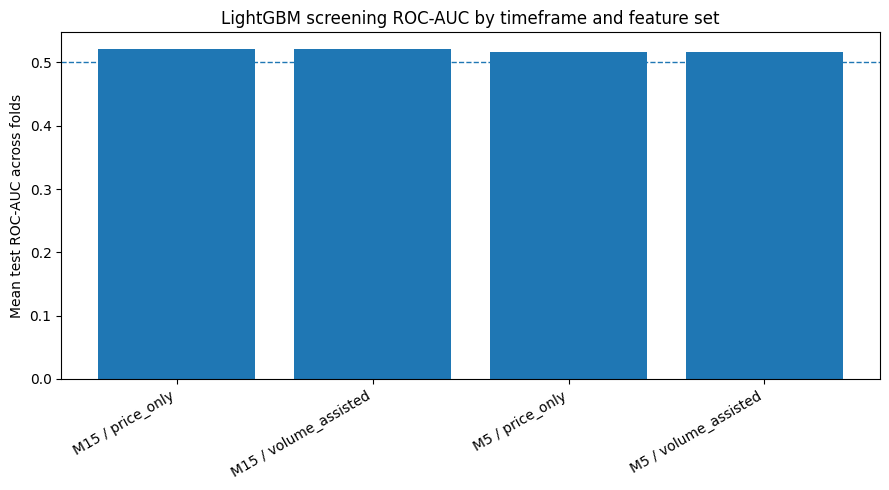

Saved: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/figures/lightgbm_screening_roc_auc_by_track.png


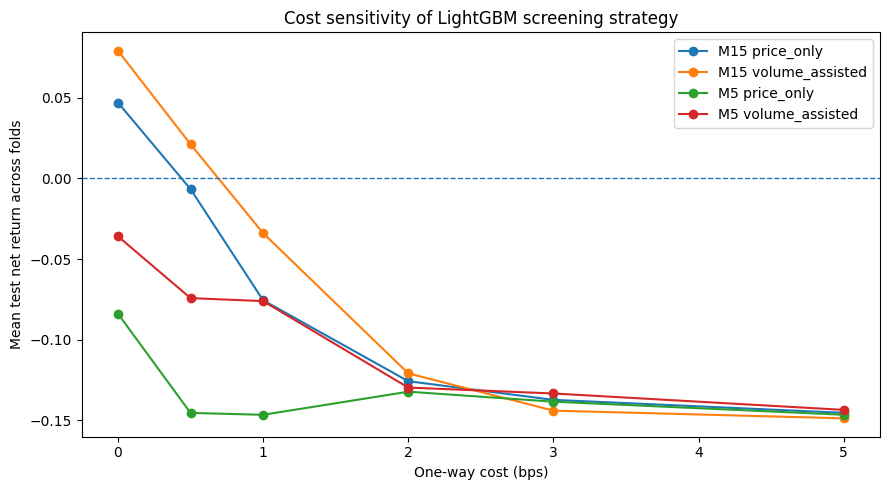

Saved: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/figures/lightgbm_screening_net_return_by_cost.png


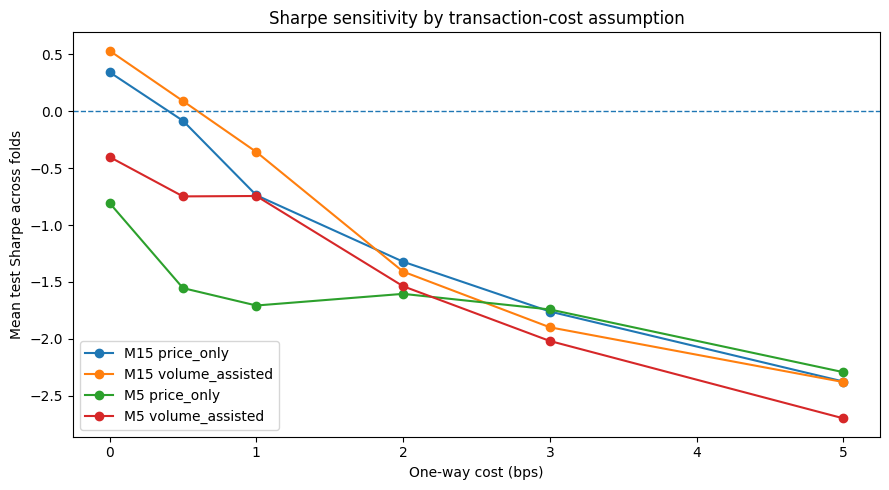

Saved: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/figures/lightgbm_screening_sharpe_by_cost.png


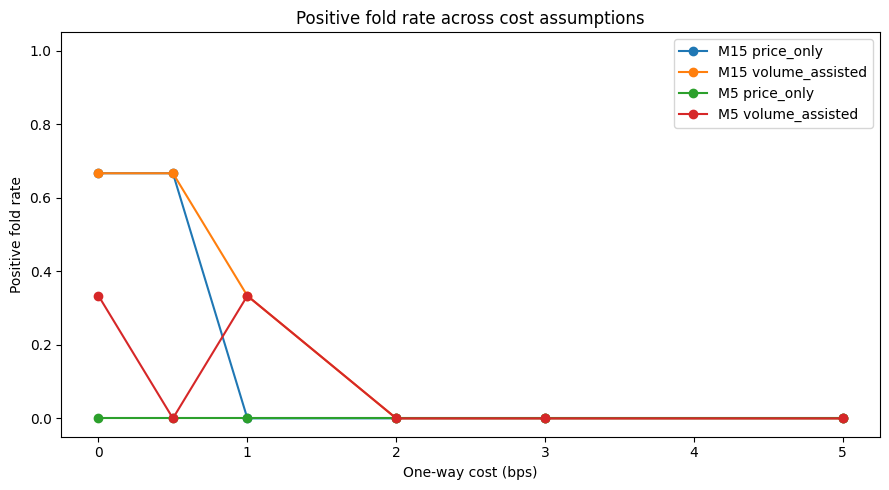

Saved: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/figures/lightgbm_screening_positive_fold_rate_by_cost.png


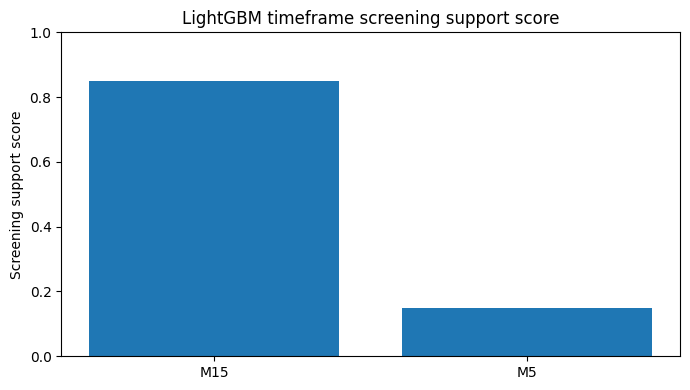

Saved: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/figures/lightgbm_timeframe_screening_score.png


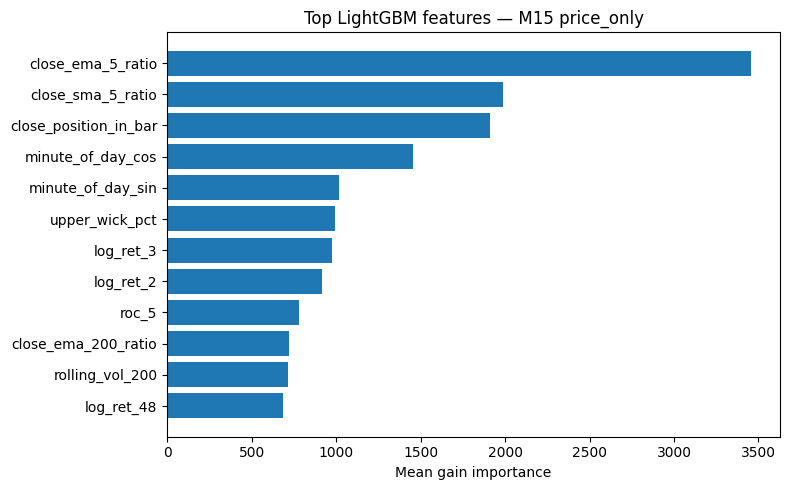

Saved: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/figures/top_features_M15_price_only.png


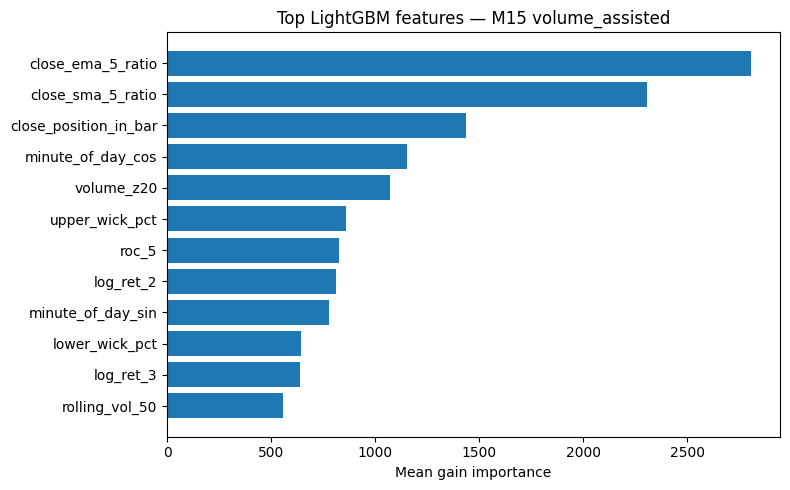

Saved: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/figures/top_features_M15_volume_assisted.png


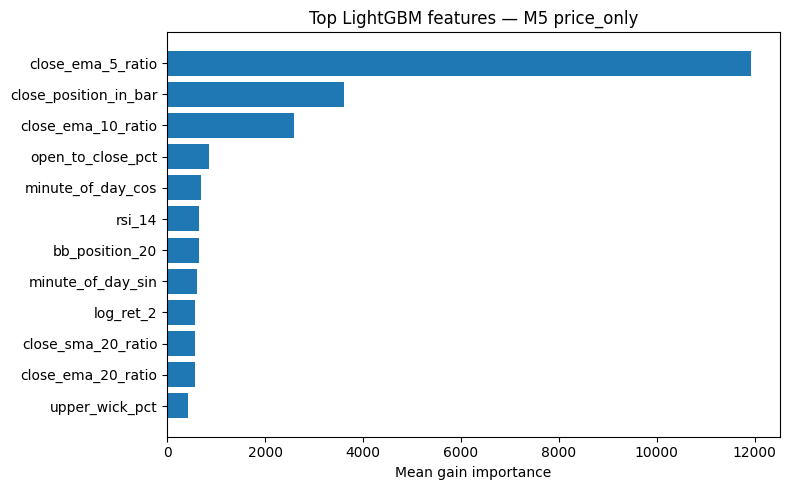

Saved: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/figures/top_features_M5_price_only.png


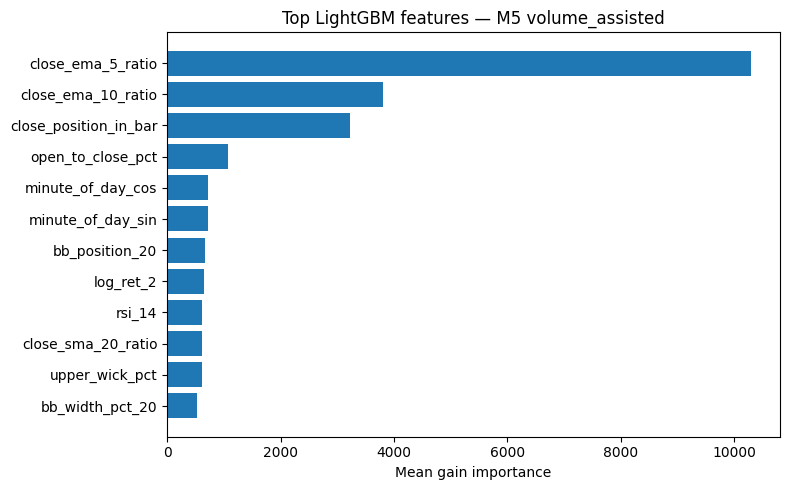

Saved: /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/figures/top_features_M5_volume_assisted.png


In [15]:
def save_current_fig(name: str):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')

fig_df = classification_agg.copy()
fig_df['label'] = fig_df['timeframe'] + ' / ' + fig_df['feature_set']
plt.figure(figsize=(9, 5))
plt.bar(fig_df['label'], fig_df['mean_roc_auc'])
plt.axhline(0.5, linestyle='--', linewidth=1)
plt.ylabel('Mean test ROC-AUC across folds')
plt.title('LightGBM screening ROC-AUC by timeframe and feature set')
plt.xticks(rotation=30, ha='right')
save_current_fig('lightgbm_screening_roc_auc_by_track.png')

plt.figure(figsize=(9, 5))
for (timeframe, feature_set), sub in trading_agg.groupby(['timeframe', 'feature_set']):
    sub = sub.sort_values('cost_bps')
    plt.plot(sub['cost_bps'], sub['mean_net_return'], marker='o', label=f'{timeframe} {feature_set}')
plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('One-way cost (bps)')
plt.ylabel('Mean test net return across folds')
plt.title('Cost sensitivity of LightGBM screening strategy')
plt.legend()
save_current_fig('lightgbm_screening_net_return_by_cost.png')

plt.figure(figsize=(9, 5))
for (timeframe, feature_set), sub in trading_agg.groupby(['timeframe', 'feature_set']):
    sub = sub.sort_values('cost_bps')
    plt.plot(sub['cost_bps'], sub['mean_sharpe'], marker='o', label=f'{timeframe} {feature_set}')
plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('One-way cost (bps)')
plt.ylabel('Mean test Sharpe across folds')
plt.title('Sharpe sensitivity by transaction-cost assumption')
plt.legend()
save_current_fig('lightgbm_screening_sharpe_by_cost.png')

plt.figure(figsize=(9, 5))
for (timeframe, feature_set), sub in trading_agg.groupby(['timeframe', 'feature_set']):
    sub = sub.sort_values('cost_bps')
    plt.plot(sub['cost_bps'], sub['positive_fold_rate'], marker='o', label=f'{timeframe} {feature_set}')
plt.xlabel('One-way cost (bps)')
plt.ylabel('Positive fold rate')
plt.title('Positive fold rate across cost assumptions')
plt.ylim(-0.05, 1.05)
plt.legend()
save_current_fig('lightgbm_screening_positive_fold_rate_by_cost.png')

plt.figure(figsize=(7, 4))
plt.bar(score_df['timeframe'], score_df['lightgbm_screening_score'])
plt.ylabel('Screening support score')
plt.title('LightGBM timeframe screening support score')
plt.ylim(0, 1)
save_current_fig('lightgbm_timeframe_screening_score.png')

for (timeframe, feature_set), sub in top_features.groupby(['timeframe', 'feature_set']):
    sub = sub.sort_values('mean_gain', ascending=True).tail(12)
    plt.figure(figsize=(8, 5))
    plt.barh(sub['feature'], sub['mean_gain'])
    plt.xlabel('Mean gain importance')
    plt.title(f'Top LightGBM features — {timeframe} {feature_set}')
    safe_feature_set = feature_set.replace('/', '_')
    save_current_fig(f'top_features_{timeframe}_{safe_feature_set}.png')

## 15. Automated findings draft

This is a draft only. It must be reviewed after the notebook runs.

In [16]:

score_lines = []
for _, row in score_df.iterrows():
    score_lines.append(
        f"- {row['timeframe']}: screening score={row['lightgbm_screening_score']:.4f}, "
        f"mean ROC-AUC={row['mean_roc_auc']:.4f}, mean net return at {main_cost} bps={row['mean_net_return']:.4f}, "
        f"positive fold rate={row['positive_fold_rate']:.2f}, mean turnover={row['mean_turnover']:.1f}"
    )

best_track = feature_level.sort_values(
    ['mean_net_return', 'mean_roc_auc', 'positive_fold_rate'],
    ascending=[False, False, False],
).iloc[0]

best_timeframe = score_df.iloc[0]['timeframe']

# These variables are created in section 11b.
try:
    viability_lines = []
    for _, row in timeframe_viability_summary.iterrows():
        viability_lines.append(
            f"- {row['timeframe']}: validation-viable fold rate={row['validation_viable_rate']:.2f}, "
            f"forced mean test net return={row['forced_mean_test_net_return']:.4f}, "
            f"gated mean test net return={row['gated_mean_test_net_return']:.4f}, "
            f"gated positive fold rate={row['gated_positive_fold_rate']:.2f}"
        )
except NameError:
    viability_lines = ['- Validation-viability diagnostic was not available.']

all_main_cost_mean_returns_negative = bool((feature_level['mean_net_return'] <= 0).all())

if all_main_cost_mean_returns_negative:
    profitability_warning = (
        "At the main screening cost, all feature-level tracks have negative mean net return. "
        "Therefore, Notebook 2 should not be interpreted as evidence that the strategy is profitable. "
        f"It only indicates that {best_timeframe} is the stronger timeframe candidate for the next modelling stage."
    )
else:
    profitability_warning = (
        "At least one feature-level track has positive mean net return at the main screening cost. "
        "This is still screening evidence only and must not be treated as final profitability evidence."
    )

findings = f"""
Notebook 2 LightGBM timeframe-screening findings
=================================================

Purpose
-------
This notebook benchmarks M5 and M15 using a lightweight fixed-parameter LightGBM classifier. The purpose is timeframe screening, not final model selection.

Final holdout protection
------------------------
The final holdout beginning {FINAL_HOLDOUT_START.date()} was not used. All benchmark folds ended before the final holdout.

Main screening-cost assumption
------------------------------
The main decision table uses {main_cost} bps one-way cost. Full cost sensitivity from {min(COST_BPS_GRID)} to {max(COST_BPS_GRID)} bps is saved separately.

Timeframe-level forced-trading result
-------------------------------------
{chr(10).join(score_lines)}

Validation-viability diagnostic
-------------------------------
{chr(10).join(viability_lines)}

Best forced-trading track at the main screening cost
----------------------------------------------------
The best feature-level track by mean test net return was {best_track['timeframe']} / {best_track['feature_set']}.
Mean test ROC-AUC: {best_track['mean_roc_auc']:.4f}
Mean test net return at {main_cost} bps: {best_track['mean_net_return']:.4f}
Mean test Sharpe: {best_track['mean_sharpe']:.4f}
Positive fold rate: {best_track['positive_fold_rate']:.2f}

Profitability warning
---------------------
{profitability_warning}

Interpretation warning
----------------------
A timeframe should not be selected from one metric alone. The preferred timeframe should show reasonable classification discrimination, cost-adjusted trading performance, positive fold consistency, and acceptable turnover/drawdown. If the stronger timeframe still has negative mean net return and weak positive-fold consistency, the correct conclusion is not that the strategy is ready, but that the selected timeframe is the more defensible candidate for the full model comparison.

Suggested next step
-------------------
If the relative comparison is stable, select the stronger timeframe for the full LightGBM/LSTM/CNN-LSTM methodology. However, do not claim profitability from this notebook. The next modelling notebooks must test whether stronger modelling and tuned configurations can improve robustness under walk-forward evaluation and realistic cost controls.
""".strip()

findings_path = OUTPUT_DIR / 'lightgbm_screening_findings_draft.txt'
findings_path.write_text(findings, encoding='utf-8')
print(findings)
print(f'\nSaved: {findings_path}')


Notebook 2 LightGBM timeframe-screening findings

Purpose
-------
This notebook benchmarks M5 and M15 using a lightweight fixed-parameter LightGBM classifier. The purpose is timeframe screening, not final model selection.

Final holdout protection
------------------------
The final holdout beginning 2025-01-01 was not used. All benchmark folds ended before the final holdout.

Main screening-cost assumption
------------------------------
The main decision table uses 1.0 bps one-way cost. Full cost sensitivity from 0.0 to 5.0 bps is saved separately.

Timeframe-level forced-trading result
-------------------------------------
- M15: screening score=0.8500, mean ROC-AUC=0.5213, mean net return at 1.0 bps=-0.0548, positive fold rate=0.17, mean turnover=1219.0
- M5: screening score=0.1500, mean ROC-AUC=0.5170, mean net return at 1.0 bps=-0.1114, positive fold rate=0.17, mean turnover=922.0

Validation-viability diagnostic
-------------------------------
- M15: validation-viable fold rate=0.

## 16. Output inventory

In [17]:
print('Tables:')
for path in sorted(TABLE_DIR.glob('*.csv')):
    print('-', path)

print('\nFigures:')
for path in sorted(FIGURE_DIR.glob('*.png')):
    print('-', path)

print('\nOther outputs:')
for path in sorted(OUTPUT_DIR.glob('*.txt')):
    print('-', path)

Tables:
- /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/aggregate_test_classification_summary.csv
- /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/aggregate_test_trading_summary_by_cost.csv
- /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/feature_importance_by_fold.csv
- /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/feature_importance_summary.csv
- /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/feature_level_screening_summary_at_main_cost.csv
- /content/drive/MyDrive/fyp_master_starter/data/capstone_methodology/notebook_outputs/02_m5_m15_lightgbm_screening/tables/lightgbm_classification_metrics_by_fold.csv
- /content/dri

## 17. Council-style review checklist after execution

After running this notebook, review:

1. Whether one timeframe wins consistently across classification and trading metrics.
2. Whether any result survives realistic cost assumptions.
3. Whether volume-assisted features improve or weaken the benchmark.
4. Whether selected thresholds are stable or unstable across folds.
5. Whether fold-level results are consistent or driven by one lucky period.
6. Whether turnover and drawdown are acceptable.

Only after this review should the final modelling timeframe be selected.